In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
analysis_path ='/home/hpc/a104bc/a104bc20/analysis/froth/'
sys.path.append(analysis_path)

<h2 style="font-family: Gill Sans; letter-spacing: 1px;"> Simulation Snapshot</h2>

In [5]:
from froth import SnapData, SnapConfig, BubbleClassifier, BubbleExtractor
from froth.utils import cylindrical_boundary_mask

In [9]:
# view available 3D models
BubbleClassifier.list_models(display = True, model_type = '3d');

Name            Type Features                            Trained      Config              
------------------------------------------------------------------------------------------
aerate_3d       3D  ρ and T aware                       2026-02-13   aerate_3d.yaml      
aerate_3d_den   3D  ρ aware                             2026-02-13   aerate_3d_den_only.yaml
aerate_3d_hot   3D  ρ and T aware, hard negatives       2026-02-13   aerate_3d_hot.yaml  


In [13]:
# First-time setup: create a config file and edit the paths inside
# froth.create_default_config()  # uncomment to generate config.yaml

# Update 'snapshot_path' and output directories in config.yaml before proceeding
path_to_config = './config.yaml'

In [14]:
# load snapshot 151 with temperature and time, restricting to |z| < 1.0 kpc and 8 < R < 10 kpc 
snap = SnapData(151, config_file = path_to_config, 
                load_options = {'temperature': True, 'z_limit': 1.0, 'time': True, 
                                'R_min': 8, 'R_max': 10, 'pad': 0.0001}, 
                rebuild_voronoi=False, voronoi_n_jobs = 6)

Voronoi files missing or rebuild requested.
░░░░░░░░░░░░░░ computing Voronoi... ░░░░░░░░░░░░░░
-----> loading snapshot 151...
   ✔   snapshot loaded
   Using n_jobs=6 (recommended: 34)
 ∘-∘ ∘ building Voronoi diagram: 4 chunks, 19,892,660 particles ∘-∘ ∘ 
 ∘-∘-∘ Voronoi complete: 305.2s ∘-∘-∘ 


**Note:** When providing custom data, `snap_num` acts as an identifier for the dataset to load later.

In [17]:
# number of gas particles in this snapshot (after masking)
snap.num_particles

19892660

In [24]:
# configure classification: 4 parallel jobs, use cached resul%notebooks if available
# set normalize=False if not working with a disk galaxy
snap_inner_config = SnapConfig(n_jobs = 4, force_recompute = False, 
                               detection_threshold = 0.5)

# initialise classifier
classifier = BubbleClassifier(model_name='aerate_3d', 
                              processing_config = snap_inner_config)

In [25]:
%%time
# run classifier — results stored in snap.labels
classifier.aerate_snapshot(snap, save_results = True)

-----> normalizing temperature with vertical profile ...
-----> creating vertical temperature profile ...
-----> creating temperature scaler ...
   ✔   temperature scaled.
-----> normalizing density with vertical profile ...
-----> creating vertical density profile ...
-----> creating density scaler ...
   ✔   density scaled.
◦ ○ ◎ aerating: 4 Voronoi chunks with 4 parallel jobs ... ◎ ○ ◦
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
-----> loading model aerate_3d ...
-----> loading model aerate_3d ...
-----> loading model aerate_3d ...
-----> loading model aerate_3d ...
   ✔   model loaded
   ·   features: ['temperature', 'density']
   ✔   model loaded
   ✔   model loaded
   ·   features: ['temperature', 'density']
   ·   device: cpu
   ·   features: ['temperature', 'density']
   ✔   model loaded
   ·   device: cpu
   ·   device: cpu
   ·   features: ['temperature', 'density']
   ·   device: cpu
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:   1

CPU times: user 8min 39s, sys: 1min 41s, total: 10min 21s
Wall time: 33.1 s


In [47]:
# mask to a cylindrical region of interest for open fraction calculations
boundary_mask = cylindrical_boundary_mask(snap.pos_R, snap.pos[:, 2], 
                                          R_limits=[8, 10], z_lims=[-1., 1.])

# extract and group bubbles; adjust peel_iteration, chunk_size and other parameters to your system
extractor = BubbleExtractor(snap, force_recompute=False, 
                            boundary_mask = boundary_mask,
                            skip_shell = False, 
                            inner_params = {'peel_iteration': 5, 
                                            'single_connect': 1, 
                                            'connect': 1, 
                                            'threshold': 0.2},
                            shell_params = {'max_layer': 6, 
                                            'inner_connect': 1,
                                            'connect': 1, 
                                            'max_iter': 10})

In [48]:
%%time
#run extraction  — results stored in snap.bubble_groups
extractor.knock_snapshot()

(((●))) knocking (((●)))
-----> extracting k-core components (5 peeling iterations) ...
   ◈   iter 0 | min_size: 5 | scanned: 5692595 | components: 516
   ◈   iter 1 | min_size: 5 | scanned: 4359686 | components: 593
   ◈   iter 2 | min_size: 5 | scanned: 3280037 | components: 618
   ◈   iter 3 | min_size: 5 | scanned: 2415469 | components: 523
   ◈   iter 4 | min_size: 5 | scanned: 1747455 | components: 587
   ✔   done in 14.0s
-----> re-growing 2159 components ...
   ◈   iter 4 | t: 2.6s | assigned: 1828285
   ◈   iter 3 | t: 6.3s | assigned: 2465529
   ◈   iter 2 | t: 6.1s | assigned: 3302477
   ◈   iter 1 | t: 4.8s | assigned: 4365586
   ◈   iter 0 | t: 6.8s | assigned: 5681655
   ✔   done 
-----> merging groups with total overlap greater than 0.2 ...
   ·   1702 candidate groups ...
   ◈   iter 0 | t: 20.4s | groups: 2159 → 1277
   ·   820 candidate groups ...
   ◈   iter 1 | t: 10.0s | groups: 1277 → 1216
   ·   751 candidate groups ...
   ◈   iter 2 | t: 9.3s | groups: 1216 → 1

CPU times: user 11min 25s, sys: 35.8 s, total: 12min 1s
Wall time: 1min 47s


<h3 style="font-family: Gill Sans; letter-spacing: 1px;"> Results</h3>

In [49]:
from froth import plots

In [50]:
# mask to a thin slice for visualisation
mask_z = plots.mask_pos_slice(snap.pos[:, 2], 0, thickness = 0.05)
mask_phi = plots.mask_pos_range(snap.pos_phi, 0, 0.125*np.pi)
mask_plot = mask_z & mask_phi

mask_bg = snap.bubble_groups == -1
mask_shell = (~snap.labels) & (~mask_bg)

# bubble_groups: integer group ID per particle, NaN for background
bubble_groups = snap.bubble_groups.copy().astype(float)
bubble_groups[bubble_groups == -1] = np.nan
bubble_groups[snap.labels] = np.nan

# classify regions: 0 = background, 1 = inner bubble, 2 = shell
mask_bubble = np.full(snap.labels.size, 0)
mask_bubble[snap.labels] = 1
mask_bubble[mask_shell] = 2

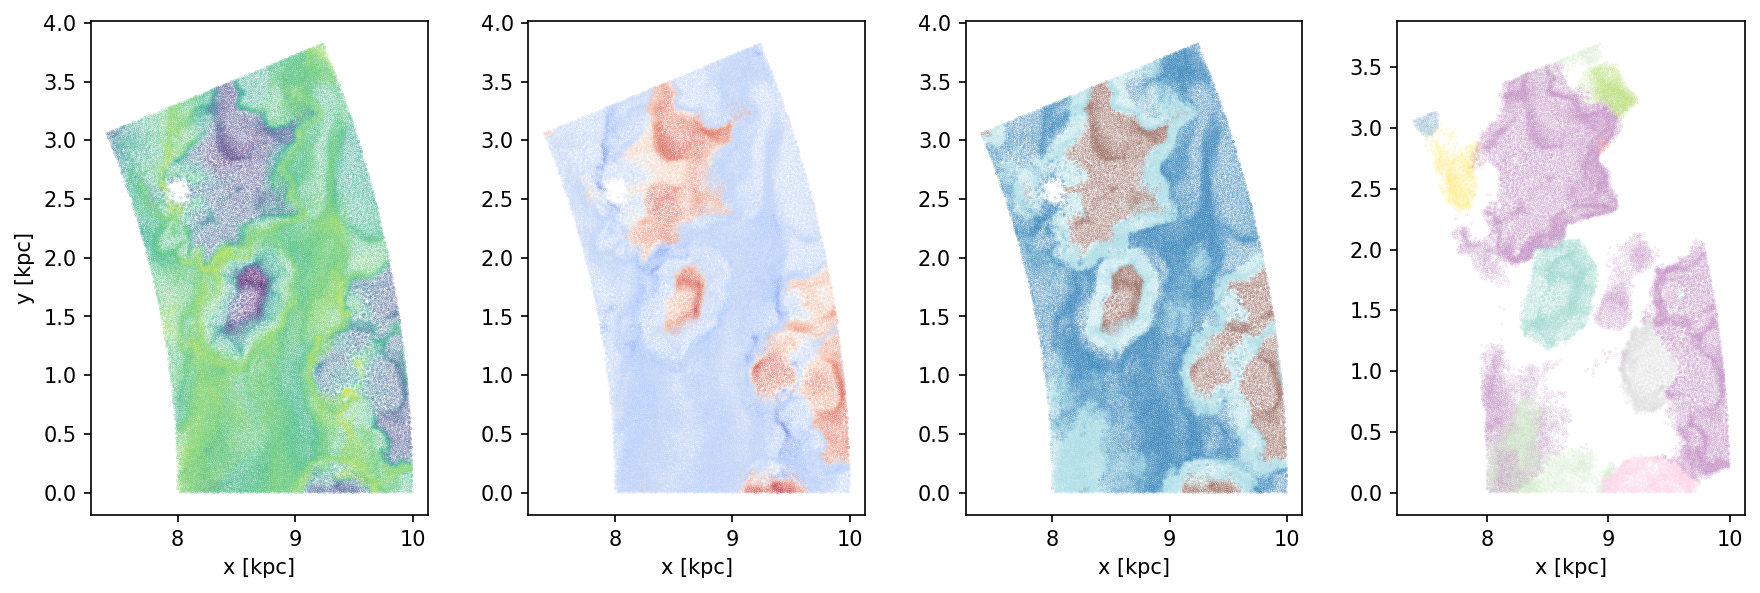

In [51]:
# panels (x-y plane): log density | log temperature | inner/shell mask | bubble group (shell) IDs
fig, ax = plots.plot_gas_scatter_2d(snap.pos[mask_plot], 
                  [np.log10(snap.den[mask_plot]), np.log10(snap.tem[mask_plot]), 
                   mask_bubble[mask_plot], bubble_groups[mask_plot]],
                            cmaps = ['viridis', 'coolwarm', 'tab20', 'Set3'],
                  plot_axes = [0, 1], figsize =(12, 4))

In [62]:
# extract particles along a 1D line through (x=8.6, z=0)
mask_line = plots.mask_line(snap.pos, x_pos=8.6, z_pos=0, thickness= 0.02)

(<Figure size 900x600 with 4 Axes>,
 array([<Axes: xlabel='Y [kpc]', ylabel='$\\log$ $\\rho$ [g/cm$^{3}$]'>,
        <Axes: xlabel='Y [kpc]', ylabel='$\\log$ T [K]'>], dtype=object))

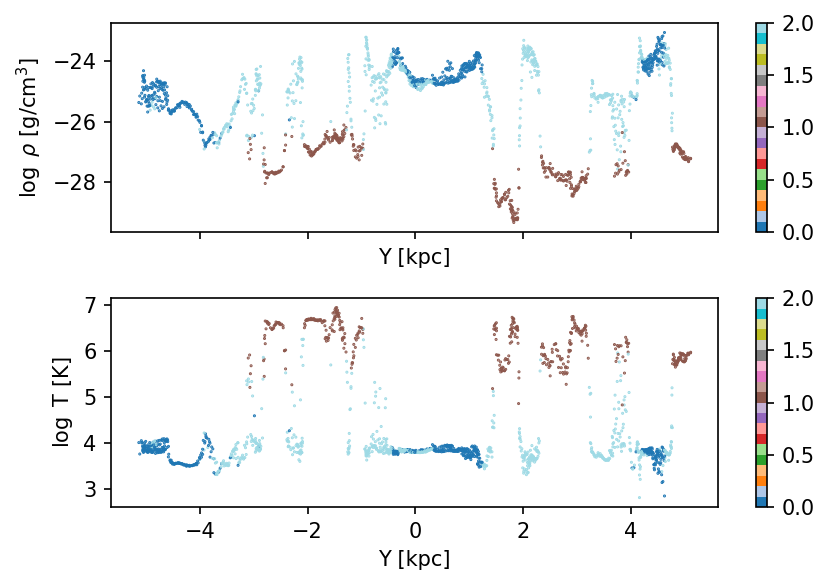

In [63]:
# line profiles of density and temperature, colored by region (inner/shell/background)
plots.plot_gas_line_profiles(snap.pos, axis=['y', 'y'], masks = [mask_line, mask_line], 
                             quantities = [np.log10(snap.den), np.log10(snap.tem)], 
                             color_quantities=[mask_bubble, mask_bubble],
                             cmaps=['tab20', 'tab20'],
                             ylabel = [r'$\log$ $\rho$ [g/cm$^{3}$]', '$\log$ T [K]'], 
                             marker_size = 0.2, plot_w_size = 6, plot_h_size = 2)

<h2 style="font-family: Gill Sans; letter-spacing: 1px;"> Galaxy Image </h2>

In [2]:
from froth import ImageData, ImageConfig, BubbleClassifier, BubbleExtractor

In [39]:
# view available 3D models
BubbleClassifier.list_models(display = True, model_type = '2d');

Name            Type Features                            Trained      Config              
------------------------------------------------------------------------------------------
aerate_2d       2D  projected ρ and T aware             2026-2-22    aerate_2d.yaml      
aerate_2d_den   2D  col. den. aware                     2026-2-22    aerate_2d_den.yaml  


**Note:** Currently only 'aerate_2d_den' is available for observational images

In [40]:
# load image
image = ImageData.from_file('./hlsp_phangs-jwst_jwst_miri_ngc0628_f770w_v1p1_img.fits')

In [43]:
# configure classifier
img_config = ImageConfig(save_scaler = False, 
                         align = True, 
                         filter_sizes = [10, 20, 40],
                         detection_mode = 'composed', 
                         detection_threshold = 0.23, 
                         batch_size = 1000000)

classifier = BubbleClassifier('aerate_2d_den', processing_config = img_config)

In [50]:
# preprocess only — inspect result before full classification
classifier.aerate_image(image, preprocess_only=True)

-----> pre-processing image ...
   ✔   preprocessing done.


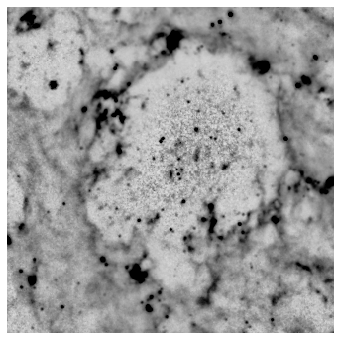

In [52]:
# inspect preprocessed image in a subregion before full classification
region = np.s_[400: 730, 260: 590]
plt.figure(figsize=(6, 6))
plt.imshow(image.data[region], origin = 'lower', cmap='Greys', 
           vmin = -0.8, vmax = 2.6, interpolation = 'none')
plt.axis('off');

In [53]:
# run full classification
classifier.aerate_image(image)

-----> pre-processing image ...
   ✔   preprocessing done.
◦ ○ ◎ aerating with a batch size of 1000000 ... ◎ ○ ◦
-----> loading all pixel neighborhood information...
   ✔    done
/home/hpc/a104bc/a104bc20/py_env/lib/python3.9/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "
-----> loading model aerate_2d_den ...
   ✔   model loaded
   ·   features: ['column density']
   ·   device: cpu
●  ●  ● aerated ●  ●  ● 


In [56]:
# extract and group bubbles from classified image
extracter = BubbleExtractor(image, 
                            inner_params = {'peel_iteration': 10, 
                                            'min_component_size': 1, 
                                            'threshold': 0.25, 
                                            'chunk_size': 1000000, 
                                            'n_jobs': 6}, 
                            shell_params = {'max_layer': 10,
                                            'connect': 1, 
                                            'max_iter': 10})

In [57]:
%%time
# run extraction
extracter.knock_image()

(((●))) knocking (((●)))
-----> extracting k-core components (10 peeling iterations) ...
   ◈   iter 0 | min_size: 1 | components: 2302
   ◈   iter 1 | min_size: 1 | components: 2211
   ◈   iter 2 | min_size: 1 | components: 2109
   ◈   iter 3 | min_size: 1 | components: 1767
   ◈   iter 4 | min_size: 1 | components: 1519
   ◈   iter 5 | min_size: 1 | components: 1348
   ◈   iter 6 | min_size: 1 | components: 1145
   ◈   iter 7 | min_size: 1 | components: 1029
   ◈   iter 8 | min_size: 1 | components: 945
   ◈   iter 9 | min_size: 1 | components: 841
   ✔   done in 21.0s
-----> re-growing 8092 components ...
-----> loading all neighborhood information...
   ✔    done
   ◈   iter 9 | t: 2.9s | assigned: 523392
   ◈   iter 8 | t: 0.4s | assigned: 549342
   ◈   iter 7 | t: 0.4s | assigned: 590562
   ◈   iter 6 | t: 0.5s | assigned: 642903
   ◈   iter 5 | t: 0.4s | assigned: 705721
   ◈   iter 4 | t: 0.5s | assigned: 781891
   ◈   iter 3 | t: 0.6s | assigned: 870745
   ◈   iter 2 | t: 0.5s

CPU times: user 2min 42s, sys: 9.06 s, total: 2min 51s
Wall time: 1min 35s


<h3 style="font-family: Gill Sans; letter-spacing: 1px;"> Results</h3>

In [65]:
# prepare group labels for visualisation
inner_groups = image.inner_assigned.reshape(image.data.shape).astype(float)
inner_groups[inner_groups == -1] = np.nan

bubble_groups = image.bubble_groups.astype(float)
bubble_groups[bubble_groups == -1] = np.nan

# shuffle colormap labels for visual contrast between adjacent groups
def shuffle_labels(markers):
    labels = np.unique(markers)
    np.random.shuffle(labels)
    markers_new = markers.copy()
    for ind in range(len(labels)):
        if labels[ind] == 0:
            continue
        markers_new[markers == labels[ind]] = ind + 1
    return markers_new

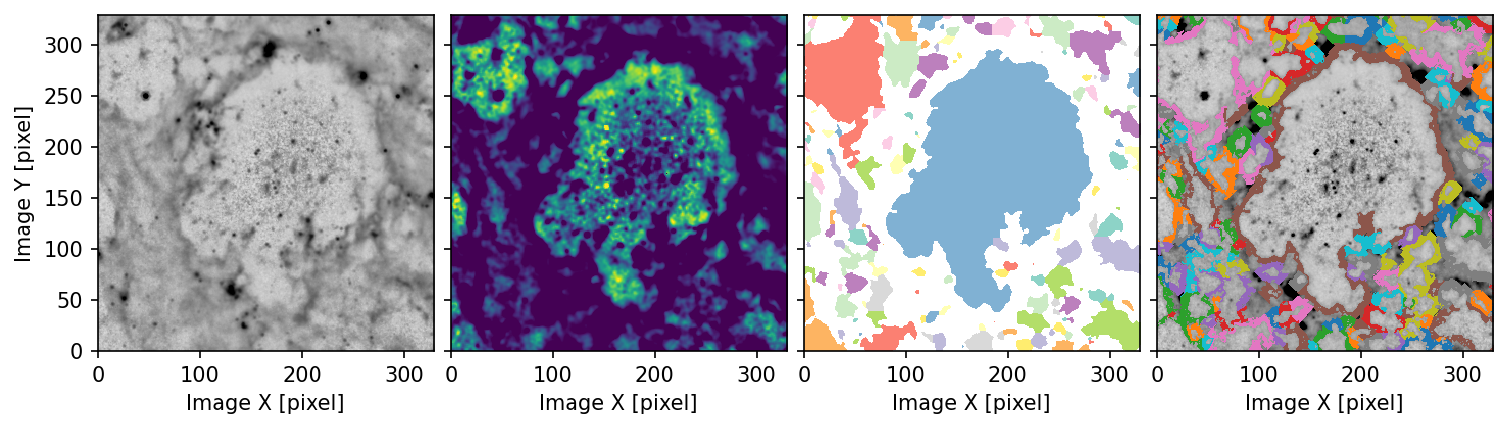

In [67]:
# plot: raw image | classification probability | inner mask | bubble groups
region = np.s_[400: 730, 260: 590]

fig, ax = plt.subplots(1, 4, figsize=(12, 4), dpi = 150, sharex = True, sharey = True)
plt.subplots_adjust(wspace = 0.05)

ax[0].imshow(np.arcsinh(image.data[region]), origin = 'lower', 
             cmap='Greys', vmin = -0.8, vmax = 2.6, interpolation = 'none')
ax[1].imshow(image.probs[region], vmin = 0.2, vmax = 0.8, origin='lower', 
             interpolation = 'none')
ax[2].imshow(shuffle_labels(inner_groups[region]), origin='lower', 
             cmap = 'Set3', interpolation = 'none')
ax[3].imshow(image.data[region], origin = 'lower', cmap='Greys', 
             vmin = -0.8, vmax = 2.6, interpolation = 'none')
shell = (image_composed.bubble_groups != -1) & (image_composed.inner != 1)
shell = np.where(shell, image.bubble_groups, np.nan)
ax[3].imshow(shuffle_labels(shell[region]), origin='lower', cmap='tab10', 
                interpolation='none')
for ax_i in ax:
    ax_i.set_xlabel('Image X [pixel]');
ax[0].set_ylabel('Image Y [pixel]');

### Two modes for image data:

##### Option 1: Composed Gaussian-normalized images (used in paper)

In [4]:
image_composed = ImageData.from_file('/home/hpc/a104bc/a104bc20/analysis/extract_bubbles_GNN/hlsp_phangs-jwst_jwst_miri_ngc0628_f770w_v1p1_img.fits')
img_config_composed = ImageConfig(save_scaler = False, 
                                  align = True, 
                                  filter_sizes = [10, 20, 40],
                                  detection_mode = 'composed', 
                                  detection_threshold = 0.23, 
                                  batch_size = 1000000)
classifier_composed = BubbleClassifier('aerate_2d_den', 
                                       processing_config = img_config_composed)

In [5]:
classifier_composed.aerate_image(image_composed)

-----> pre-processing image ...
   ✔   preprocessing done.
◦ ○ ◎ aerating with a batch size of 1000000 ... ◎ ○ ◦
-----> loading all pixel neighborhood information...
   ✔    done
/home/hpc/a104bc/a104bc20/py_env/lib/python3.9/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "
-----> loading model aerate_2d_den ...
   ✔   model loaded
   ·   features: ['column density']
   ·   device: cpu
●  ●  ● aerated ●  ●  ● 


In [6]:
extracter = BubbleExtractor(image_composed, 
                            inner_params = {'peel_iteration': 10, 
                                            'min_component_size': 1, 
                                            'threshold': 0.25, 
                                            'chunk_size': 1000000, 
                                            'n_jobs': 6}, 
                            shell_params = {'max_layer': 10,
                                            'connect': 1, 
                                            'max_iter': 10})
extracter.knock_image()

(((●))) knocking (((●)))
-----> extracting k-core components (10 peeling iterations) ...
   ◈   iter 0 | min_size: 1 | components: 2302
   ◈   iter 1 | min_size: 1 | components: 2211
   ◈   iter 2 | min_size: 1 | components: 2109
   ◈   iter 3 | min_size: 1 | components: 1767
   ◈   iter 4 | min_size: 1 | components: 1519
   ◈   iter 5 | min_size: 1 | components: 1348
   ◈   iter 6 | min_size: 1 | components: 1145
   ◈   iter 7 | min_size: 1 | components: 1029
   ◈   iter 8 | min_size: 1 | components: 945
   ◈   iter 9 | min_size: 1 | components: 841
   ✔   done in 21.0s
-----> re-growing 8092 components ...
-----> loading all neighborhood information...
   ✔    done
   ◈   iter 9 | t: 2.2s | assigned: 523392
   ◈   iter 8 | t: 3.2s | assigned: 549342
   ◈   iter 7 | t: 0.4s | assigned: 590562
   ◈   iter 6 | t: 0.4s | assigned: 642903
   ◈   iter 5 | t: 0.4s | assigned: 705721
   ◈   iter 4 | t: 0.5s | assigned: 781891
   ◈   iter 3 | t: 0.6s | assigned: 870745
   ◈   iter 2 | t: 0.5s

##### Option 2: Per-image Gaussian normalization, assign to max.

In [21]:
image_max = ImageData.from_file('/home/hpc/a104bc/a104bc20/analysis/extract_bubbles_GNN/hlsp_phangs-jwst_jwst_miri_ngc0628_f770w_v1p1_img.fits')
img_config_max = ImageConfig(save_scaler = False, 
                             align = True, 
                             filter_sizes = [10, 20, 40],
                             detection_mode = 'max', 
                             detection_threshold = 0.25, 
                             batch_size = 1000000)
classifier_max = BubbleClassifier('aerate_2d_den', 
                              processing_config = img_config_max)

In [22]:
classifier_max.aerate_image(image_max)

-----> pre-processing image ...
   ✔   preprocessing done.
◦ ○ ◎ aerating with a batch size of 1000000 ... ◎ ○ ◦
-----> loading all pixel neighborhood information...
   ✔    done
/home/hpc/a104bc/a104bc20/py_env/lib/python3.9/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "
-----> loading model aerate_2d_den ...
   ✔   model loaded
   ·   features: ['column density']
   ·   device: cpu
●  ●  ● aerated ●  ●  ● 


In [23]:
extracter = BubbleExtractor(image_max, 
                            inner_params = {'peel_iteration': 10, 
                                            'min_component_size': 1, 
                                            'threshold': 0.25, 
                                            'chunk_size': 10000000, 
                                            'n_jobs': 6},
                            shell_params = {'max_layer': 10,
                                            'connect': 1, 
                                            'max_iter': 10})
extracter.knock_image()

(((●))) knocking (((●)))
-----> extracting k-core components (10 peeling iterations) ...
   ◈   iter 0 | min_size: 1 | components: 2348
   ◈   iter 1 | min_size: 1 | components: 2332
   ◈   iter 2 | min_size: 1 | components: 2243
   ◈   iter 3 | min_size: 1 | components: 1908
   ◈   iter 4 | min_size: 1 | components: 1613
   ◈   iter 5 | min_size: 1 | components: 1354
   ◈   iter 6 | min_size: 1 | components: 1142
   ◈   iter 7 | min_size: 1 | components: 908
   ◈   iter 8 | min_size: 1 | components: 815
   ◈   iter 9 | min_size: 1 | components: 697
   ✔   done in 21.0s
-----> re-growing 8202 components ...
-----> loading all neighborhood information...
   ✔    done
   ◈   iter 9 | t: 2.3s | assigned: 651173
   ◈   iter 8 | t: 0.4s | assigned: 681461
   ◈   iter 7 | t: 0.4s | assigned: 725984
   ◈   iter 6 | t: 0.4s | assigned: 780307
   ◈   iter 5 | t: 0.4s | assigned: 844539
   ◈   iter 4 | t: 0.6s | assigned: 920633
   ◈   iter 3 | t: 0.5s | assigned: 1010584
   ◈   iter 2 | t: 0.5s

##### A comparision between two modes

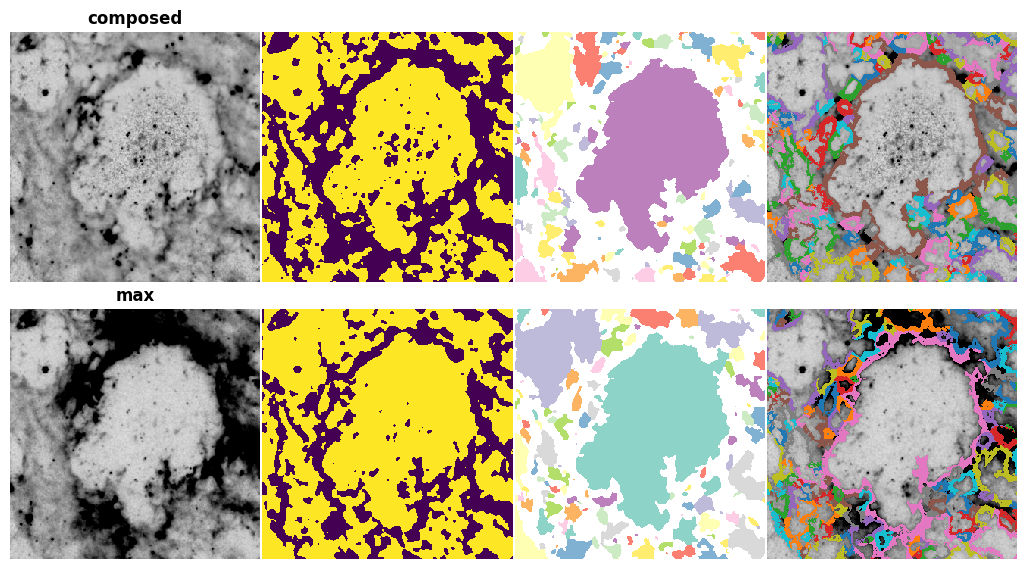

In [37]:
region = np.s_[400: 730, 260: 590]
fig, ax = plt.subplots(2, 4, figsize=(13, 7.), dpi = 100)
plt.subplots_adjust(wspace = 0.01, hspace = 0.1)

ax[0, 0].set_title('composed', fontweight='bold')
ax[0, 0].imshow(image_composed.data[region], origin = 'lower', cmap='Greys', 
             vmin = -0.8, vmax = 2.6, interpolation = 'none')
ax[0, 1].imshow(image_composed.probs[region] > 0.2, origin = 'lower', cmap='viridis', 
             vmin = 0.0, vmax = 1.0, interpolation = 'none')

inner_groups = image_composed.inner_assigned.reshape(image_composed.data.shape)
ax[0, 2].imshow(shuffle_labels(inner_groups[region]), 
                origin = 'lower', cmap='Set3', interpolation = 'none')
ax[0, 3].imshow(image_composed.data[region], origin = 'lower', cmap='Greys', 
             vmin = -0.8, vmax = 2.6, interpolation = 'none')
shell_composed = (image_composed.bubble_groups != -1) & (image_composed.inner != 1)
shell_composed = np.where(shell_composed, image_composed.bubble_groups, np.nan)
ax[0, 3].imshow(shuffle_labels(shell_composed[region]), origin='lower', cmap='tab10', 
                interpolation='none')

ax[1, 0].set_title('max', fontweight='bold')
ax[1, 0].imshow(image_max.data[region], origin = 'lower', cmap='Greys', 
             vmin = -0.8, vmax = 2.6, interpolation = 'none')
ax[1, 1].imshow(image_max.probs[region] > 0.2, origin = 'lower', cmap='viridis', 
             vmin = 0.0, vmax = 1.0, interpolation = 'none')

inner_groups = image_max.inner_assigned.reshape(image_max.data.shape)
ax[1, 2].imshow(shuffle_labels(inner_groups[region]), 
                origin = 'lower', cmap='Set3', interpolation = 'none')
ax[1, 3].imshow(image_max.data[region], origin = 'lower', cmap='Greys', 
             vmin = -0.8, vmax = 2.6, interpolation = 'none')
shell_max = (image_max.bubble_groups != -1) & (image_max.inner != 1)
shell_max = np.where(shell_max, image_max.bubble_groups, np.nan)
ax[1, 3].imshow(shuffle_labels(shell_max[region]), origin='lower', cmap='tab10', 
                interpolation='none')

for ax_i in ax.ravel():
    ax_i.axis('off')